# Descriptive Statistics – Practical

We'll explore descriptive statistics hands-on using NumPy, Pandas, Matplotlib, and SciPy on a real-world dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

## 1. Load Dataset

We'll use the classic **Iris** dataset (built into seaborn) — 150 flower measurements across 3 species.

In [2]:
from sklearn.datasets import load_iris

# Loaded from scikit-learn's bundled copy (no network dependency) and
# renamed to match seaborn's familiar iris column names.
_iris = load_iris(as_frame=True)
df = _iris.frame.rename(columns={
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)': 'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)': 'petal_width',
})
df['species'] = df['target'].map(dict(enumerate(_iris.target_names)))
df = df.drop(columns='target')

print(df.shape)
df.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Quick summary of data types and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


## From-Scratch: Mean, Variance, Std Dev, Correlation

Implement each statistic directly from its mathematical definition (pure Python, no
`np.mean`/`np.var`/`np.std`/`np.corrcoef`), then verify against NumPy on the real `sepal_length`
and `petal_length` columns.

In [4]:
def mean_scratch(x):
    return sum(x) / len(x)

def variance_scratch(x, ddof=1):
    m = mean_scratch(x)
    return sum((xi - m) ** 2 for xi in x) / (len(x) - ddof)

def std_scratch(x, ddof=1):
    return variance_scratch(x, ddof) ** 0.5

def covariance_scratch(x, y):
    mx, my = mean_scratch(x), mean_scratch(y)
    n = len(x)
    return sum((xi - mx) * (yi - my) for xi, yi in zip(x, y)) / (n - 1)

def correlation_scratch(x, y):
    return covariance_scratch(x, y) / (std_scratch(x) * std_scratch(y))

x = df['sepal_length'].tolist()
y = df['petal_length'].tolist()

print(f"mean   scratch={mean_scratch(x):.6f}  numpy={np.mean(x):.6f}")
print(f"var    scratch={variance_scratch(x):.6f}  numpy={np.var(x, ddof=1):.6f}")
print(f"std    scratch={std_scratch(x):.6f}  numpy={np.std(x, ddof=1):.6f}")
print(f"corr   scratch={correlation_scratch(x, y):.6f}  numpy={np.corrcoef(x, y)[0, 1]:.6f}")

mean   scratch=5.843333  numpy=5.843333
var    scratch=0.685694  numpy=0.685694
std    scratch=0.828066  numpy=0.828066
corr   scratch=0.871754  numpy=0.871754


## 2. Measures of Central Tendency

In [5]:
col = 'sepal_length'

mean   = df[col].mean()
median = df[col].median()
mode   = df[col].mode()[0]  # mode() returns a Series; take first value

print(f"Mean:   {mean:.4f}")
print(f"Median: {median:.4f}")
print(f"Mode:   {mode:.4f}")

Mean:   5.8433
Median: 5.8000
Mode:   5.0000


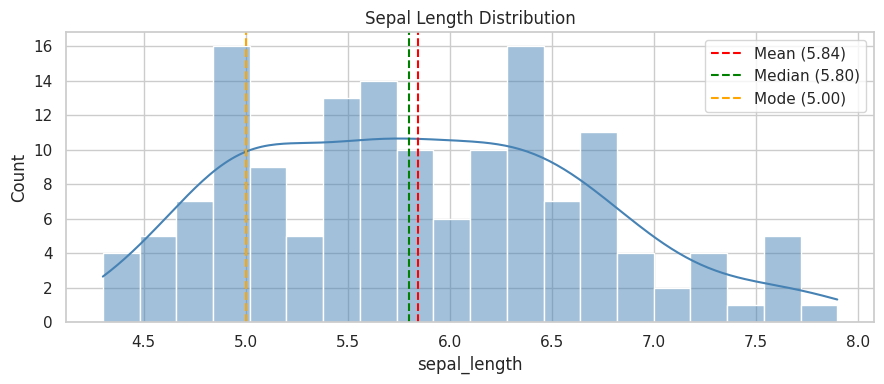

In [6]:
# Visualise where mean, median and mode fall on the distribution
plt.figure(figsize=(9, 4))
sns.histplot(df[col], bins=20, kde=True, color='steelblue')
plt.axvline(mean,   color='red',    linestyle='--', label=f'Mean ({mean:.2f})')
plt.axvline(median, color='green',  linestyle='--', label=f'Median ({median:.2f})')
plt.axvline(mode,   color='orange', linestyle='--', label=f'Mode ({mode:.2f})')
plt.title('Sepal Length Distribution')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Measures of Dispersion

In [7]:
data = df[col]

print(f"Range:    {data.max() - data.min():.4f}")
print(f"Variance: {data.var():.4f}")     # pandas uses ddof=1 (sample variance) by default
print(f"Std Dev:  {data.std():.4f}")
q1, q3 = data.quantile(0.25), data.quantile(0.75)
print(f"IQR:      {q3 - q1:.4f}")

Range:    3.6000
Variance: 0.6857
Std Dev:  0.8281
IQR:      1.3000


In [8]:
# pandas describe() gives all of the above at once
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 4. Box Plot — Five-Number Summary & Outliers

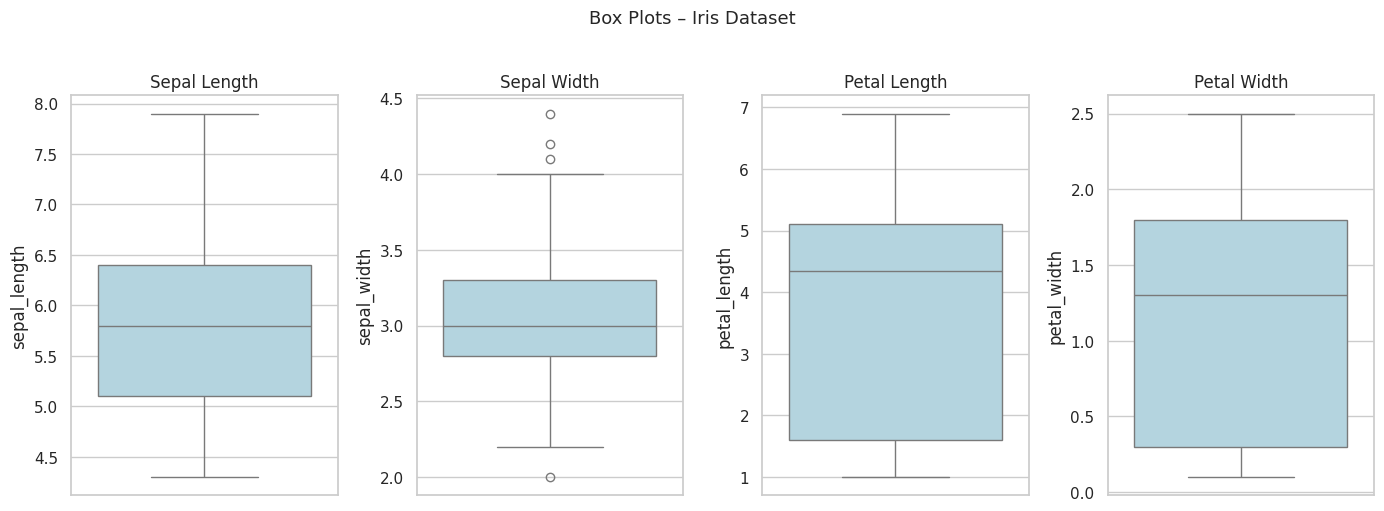

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

numeric_cols = df.select_dtypes(include='number').columns
for ax, col_name in zip(axes, numeric_cols):
    sns.boxplot(y=df[col_name], ax=ax, color='lightblue')
    ax.set_title(col_name.replace('_', ' ').title())

plt.suptitle('Box Plots – Iris Dataset', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Shape — Skewness & Kurtosis

In [10]:
for col_name in numeric_cols:
    skew = df[col_name].skew()
    kurt = df[col_name].kurt()   # pandas returns excess kurtosis (normal = 0)
    print(f"{col_name:<20} skewness={skew:+.3f}  excess kurtosis={kurt:+.3f}")

sepal_length         skewness=+0.315  excess kurtosis=-0.552
sepal_width          skewness=+0.319  excess kurtosis=+0.228
petal_length         skewness=-0.275  excess kurtosis=-1.402
petal_width          skewness=-0.103  excess kurtosis=-1.341


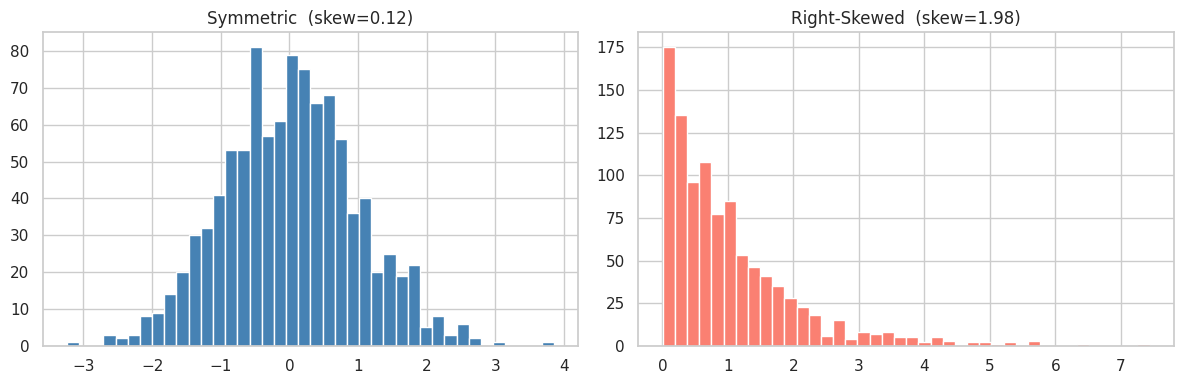

In [11]:
# Compare a right-skewed variable vs a symmetric one
np.random.seed(42)
symmetric = np.random.normal(loc=0, scale=1, size=1000)
right_skewed = np.random.exponential(scale=1, size=1000)  # exponential is right-skewed

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(symmetric, bins=40, color='steelblue', edgecolor='white')
ax1.set_title(f'Symmetric  (skew={stats.skew(symmetric):.2f})')
ax2.hist(right_skewed, bins=40, color='salmon', edgecolor='white')
ax2.set_title(f'Right-Skewed  (skew={stats.skew(right_skewed):.2f})')
plt.tight_layout()
plt.show()

## 6. Covariance & Correlation

In [12]:
# Correlation matrix
corr = df[numeric_cols].corr()
print(corr)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


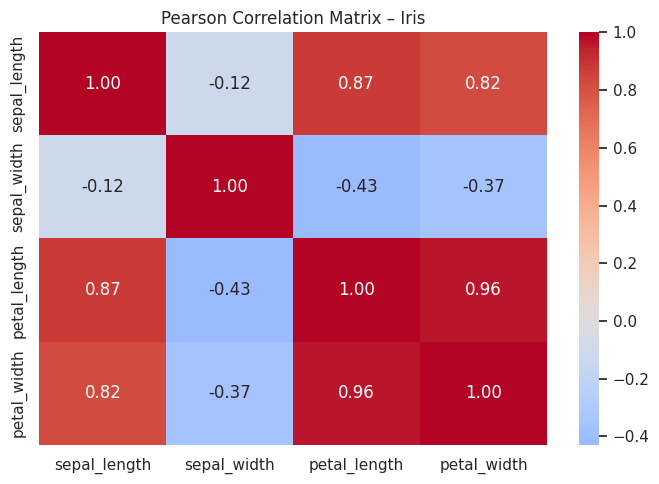

In [13]:
# Heatmap makes correlations easy to spot
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pearson Correlation Matrix – Iris')
plt.tight_layout()
plt.show()

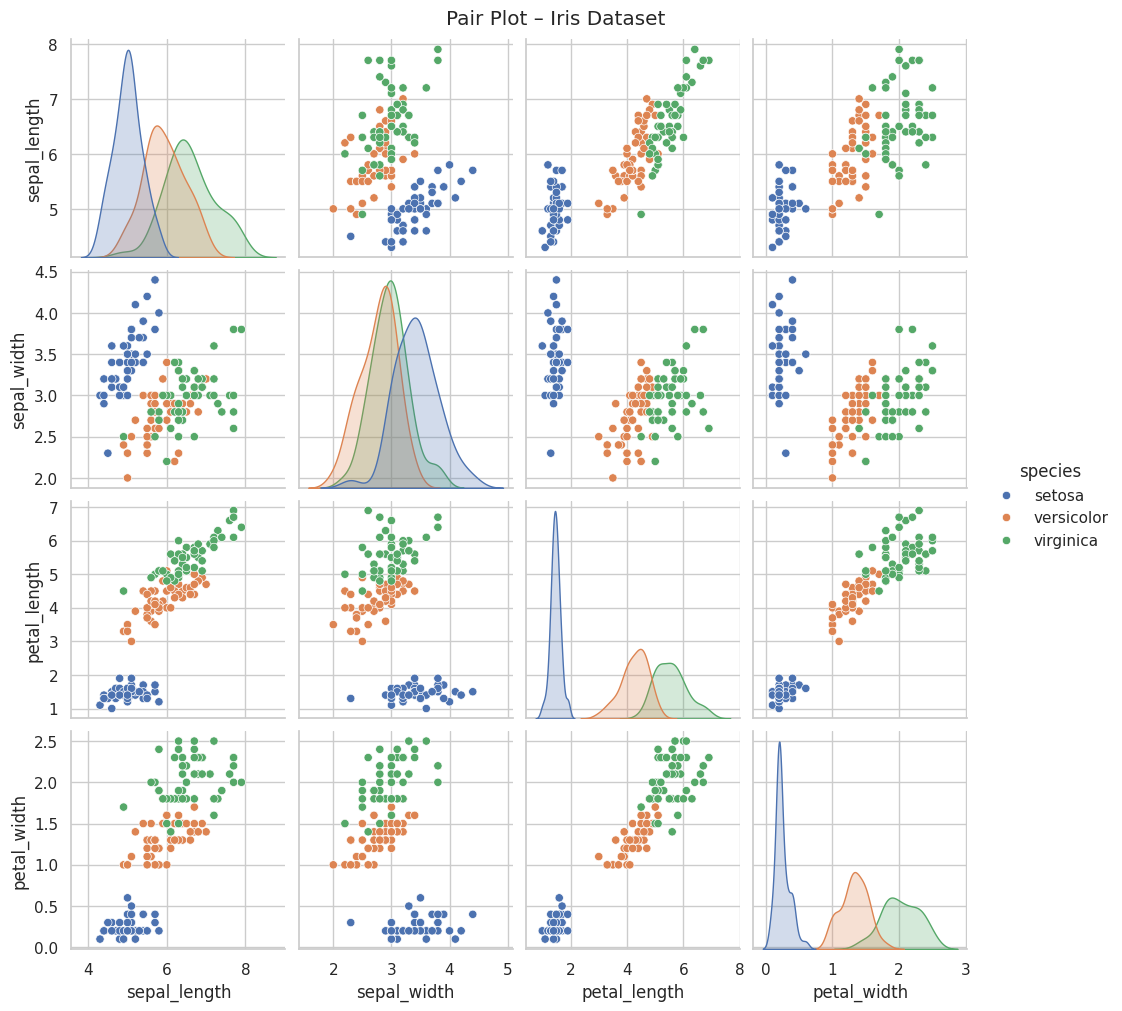

In [14]:
# Pair plot — scatter plots for every pair of features
sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle('Pair Plot – Iris Dataset', y=1.01)
plt.show()

## 7. Outlier Detection Using IQR

In [15]:
def detect_outliers_iqr(series: pd.Series) -> pd.Series:
    """Returns a boolean mask — True where a value is an outlier."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

for col_name in numeric_cols:
    mask = detect_outliers_iqr(df[col_name])
    print(f"{col_name:<20}: {mask.sum()} outlier(s)")

sepal_length        : 0 outlier(s)
sepal_width         : 4 outlier(s)
petal_length        : 0 outlier(s)
petal_width         : 0 outlier(s)


## 8. Grouped Statistics — Per Species

## 9. Experiment — Does the n vs n-1 Denominator Actually Matter?

**Hypothesis:** dividing the sum of squared deviations by `n` (population-style) systematically
*underestimates* the true variance when computed from small samples, and dividing by `n-1`
(Bessel's correction) removes that bias.

**Setup:** draw 200,000 independent samples of size 5 from a known population `N(50, 5²)` (true
variance = 25), compute the variance both ways for every sample, and average each estimator across
all 200,000 trials.

In [16]:
rng = np.random.default_rng(42)
mu, sigma = 50.0, 5.0
true_variance = sigma ** 2

sample_size = 5
n_trials = 200_000
samples = rng.normal(mu, sigma, size=(n_trials, sample_size))
means = samples.mean(axis=1, keepdims=True)
sq_dev_sum = ((samples - means) ** 2).sum(axis=1)

biased = sq_dev_sum / sample_size          # divide by n
unbiased = sq_dev_sum / (sample_size - 1)  # divide by n-1 (Bessel's correction)

print(f"true population variance (sigma^2):   {true_variance:.4f}")
print(f"mean of /n   (biased) estimator:      {biased.mean():.4f}  "
      f"(bias = {biased.mean() - true_variance:.4f}, "
      f"{100 * (true_variance - biased.mean()) / true_variance:.1f}% too low)")
print(f"mean of /(n-1) (unbiased) estimator:  {unbiased.mean():.4f}  "
      f"(bias = {unbiased.mean() - true_variance:.4f})")

true population variance (sigma^2):   25.0000
mean of /n   (biased) estimator:      20.0335  (bias = -4.9665, 19.9% too low)
mean of /(n-1) (unbiased) estimator:  25.0419  (bias = 0.0419)


In [17]:
# Group-wise mean and std — immediately useful for EDA before ML
df.groupby('species')[numeric_cols].agg(['mean', 'std']).round(2)

sepal_length       sepal_width       petal_length        \
                   mean   std        mean   std         mean   std   
species                                                              
setosa             5.01  0.35        3.43  0.38         1.46  0.17   
versicolor         5.94  0.52        2.77  0.31         4.26  0.47   
virginica          6.59  0.64        2.97  0.32         5.55  0.55   

           petal_width        
                  mean   std  
species                       
setosa            0.25  0.11  
versicolor        1.33  0.20  
virginica         2.03  0.27

/tmp/ipykernel_245272/2143223603.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y=col_name, data=df, ax=ax, palette='Set2')
/tmp/ipykernel_245272/2143223603.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y=col_name, data=df, ax=ax, palette='Set2')


/tmp/ipykernel_245272/2143223603.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y=col_name, data=df, ax=ax, palette='Set2')
/tmp/ipykernel_245272/2143223603.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y=col_name, data=df, ax=ax, palette='Set2')


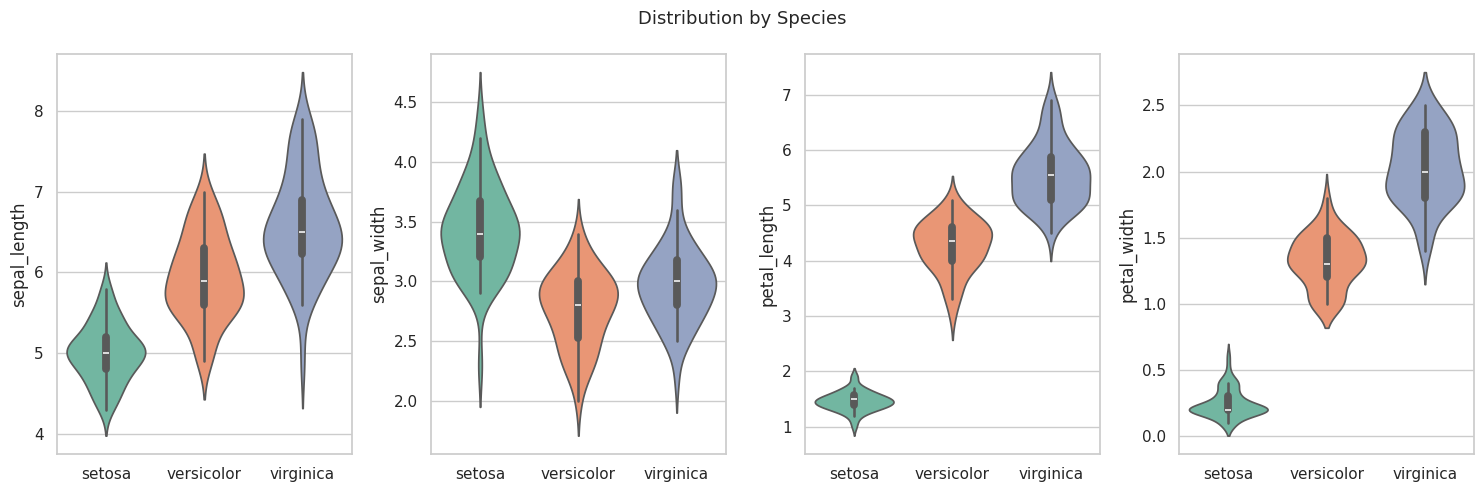

In [18]:
# Violin plot — combines box plot with KDE
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, col_name in zip(axes, numeric_cols):
    sns.violinplot(x='species', y=col_name, data=df, ax=ax, palette='Set2')
    ax.set_xlabel('')
plt.suptitle('Distribution by Species', fontsize=13)
plt.tight_layout()
plt.show()